# 컴퓨터비전입문 week09

1. cv2.canny() 함수를 이용하여 에지 검출을 해보세요.

In [ ]:
import numpy as np
import wget, cv2
wget.download('https://raw.githubusercontent.com/tysep16/CV26_1/refs/heads/main/lenna.png', './img/')
image = cv2.imread('./img/lenna.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gaussianBlur = cv2.GaussianBlur(gray, [5,5], 0)
cannyEdge = cv2.Canny(gaussianBlur, threshold1=50, threshold2=150)
cannyEdge = cv2.cvtColor(cannyEdge, cv2.COLOR_GRAY2BGR)
final_image = np.hstack([image, cannyEdge])

cv2.imshow('final', final_image)
cv2.waitKey()
cv2.destroyAllWindows()

2. 프리윗 경계 검출 기법을 이용하여 다음 코드를 완성하세요.

In [ ]:
import numpy as np
import cv2

image = cv2.imread('./img/lenna.png')

kx = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
ky = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
gx = cv2.filter2D(image, -1, kx)
gy = cv2.filter2D(image, -1, ky)
prewittEdge = cv2.addWeighted(gx, 0.5, gy, 0.5, 0)
final_image = np.hstack([image, prewittEdge])
cv2.imshow('final', final_image)
cv2.waitKey()
cv2.destroyAllWindows()

3. 소벨 경계 검출 기법을 이용하여 다음 코드를 완성하세요.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-598.0..582.0].


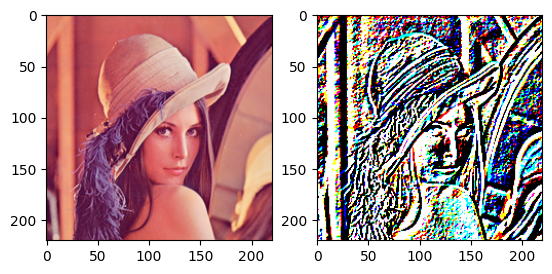

In [1]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('./img/lenna.png')
gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=3)
sobelEdge = cv2.addWeighted(gx, 0.5, gy, 0.5, 0)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
sobelEdge_rgb = cv2.cvtColor(sobelEdge, cv2.COLOR_BGR2RGB)  # float32 그대로 가능

fig, axes = plt.subplots(1, 2)
axes[0].imshow(image_rgb)
axes[1].imshow(sobelEdge_rgb)  # matplotlib은 float 자동 정규화해줌
plt.show()